# Dateset preparation

In [1]:
%matplotlib inline

In [17]:
from pathlib import Path
from typing import List, Optional, Tuple, Set, Dict
import io
import fitz  # PyMuPDF
import cv2
import numpy as np
from math import atan2, degrees, hypot, ceil
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
import uuid

try:
    from PIL import Image  # only needed for JPEG encoding
    _HAS_PIL = True
except Exception:
    _HAS_PIL = False


## Setup

In [30]:
def read_file_as_binary(file_path):
    """
    Reads a local file and returns its binary content.
    
    Args:
        file_path (str): Path to the file.
    
    Returns:
        bytes: Binary content of the file.
    """
    path = Path(file_path)
    with open(path, "rb") as f:
        binary_data = f.read()
    return binary_data

In [19]:
def pdf_bytes_to_images(
    pdf_bytes: bytes,
    dpi: int = 200,
    fmt: str = "png",                   # "png" or "jpg"
    save_dir: Optional[Path | str] = None,
    base_filename: Optional[str] = None,  # used for saved filenames only
    jpg_quality: int = 90
) -> List[bytes]:
    """
    Render each page of a (scanned) PDF (given as bytes) to images and return a list of image bytes.
    Optionally save images to disk as <base_filename>_p<page>.<ext> (1-based page numbering).

    Args:
        pdf_bytes: Raw bytes of the PDF.
        dpi: Output DPI (controls resolution). 72 dpi == 1.0 zoom.
        fmt: "png" (native via PyMuPDF) or "jpg".
        save_dir: If provided, images are also saved to this directory.
        base_filename: If saving, the basename to use (default: "document").
        jpg_quality: JPEG quality (1–95) if fmt="jpg".

    Returns:
        List of bytes objects, one per page, in the requested format.
    """
    fmt = fmt.lower()
    if fmt not in {"png", "jpg", "jpeg"}:
        raise ValueError("fmt must be 'png' or 'jpg'")

    if fmt in {"jpg", "jpeg"} and not _HAS_PIL:
        raise RuntimeError("JPEG output requires Pillow (pip install Pillow)")

    # Prepare output directory (optional)
    out_dir: Optional[Path] = None
    if save_dir is not None:
        out_dir = Path(save_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        if not base_filename:
            base_filename = "document"

    if not base_filename:
        base_filename = "document"

    # DPI -> zoom factor
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)

    images: List[bytes] = []

    # Open from bytes
    with fitz.open(stream=pdf_bytes, filetype="pdf") as doc:
        if doc.needs_pass:
            raise RuntimeError("This PDF is encrypted and needs a password.")
        page_count = doc.page_count

        for page_index, page in enumerate(doc, start=1):
            # Render to pixmap (no alpha for cleaner JPG/PNG)
            pix = page.get_pixmap(matrix=mat, alpha=False)

            if fmt == "png":
                img_bytes = pix.tobytes(output="png")  # PyMuPDF-native PNG
                ext = "png"
            else:
                # Convert Pixmap -> PIL Image -> JPEG bytes
                # pix.samples are RGB bytes; pix.stride is bytes per row
                mode = "RGB" if pix.n in (3, 4) else "L"
                pil_img = Image.frombytes(mode, (pix.width, pix.height), pix.samples)
                buf = io.BytesIO()
                pil_img.save(buf, format="JPEG", quality=jpg_quality, optimize=True)
                img_bytes = buf.getvalue()
                ext = "jpg"

            images.append(img_bytes)

            # Optional save
            if out_dir is not None:
                filename = f"{base_filename}_p{page_index}.{ext}"
                (out_dir / filename).write_bytes(img_bytes)

    return images


In [20]:
# Bounding box type: (x_min, y_min, x_max, y_max)
BBox = Tuple[int, int, int, int]


def crop_image_array(img: np.ndarray, bbox: BBox, margin=0) -> np.ndarray:
    """
    Crop an image (NumPy array) using pixel coordinates.

    Args:
        img: HxWxC or HxW image (BGR if from cv2).
        bbox: (x_min, y_min, x_max, y_max) in *pixel coordinates*.

    Returns:
        Cropped image as NumPy array.
    """
    if img is None:
        raise ValueError("crop_image_array: img is None")

    h, w = img.shape[:2]
    x_min, y_min, x_max, y_max = bbox

    # Clamp to image bounds
    x_min = int(max(0, min(x_min-margin, w)))
    x_max = int(max(0, min(x_max+margin, w)))
    y_min = int(max(0, min(y_min-margin, h)))
    y_max = int(max(0, min(y_max+margin, h)))

    if x_max <= x_min or y_max <= y_min:
        raise ValueError(f"Invalid bbox after clamping: {bbox}")

    # NumPy slices: [y_min:y_max, x_min:x_max]
    crop = img[y_min:y_max, x_min:x_max].copy()
    return crop


def crop_image_file(
    input_path: str,
    bbox: BBox,
    margin=0,
    output_path: str = None,
) -> np.ndarray:
    """
    Load an image from disk, crop by pixel bbox, optionally save.

    Args:
        input_path: path to input image.
        bbox: (x_min, y_min, x_max, y_max) in pixels.
        output_path: where to save cropped image (if not None).

    Returns:
        Cropped image as NumPy array.
    """
    img = cv2.imread(input_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {input_path}")

    crop = crop_image_array(img, bbox, margin=margin)

    if output_path is not None:
        cv2.imwrite(output_path, crop)

    return crop

def image_array_to_png_bytes(img: np.ndarray) -> bytes:
    """
    Encode an OpenCV image (np.ndarray, BGR) as PNG bytes.
    """
    ok, buf = cv2.imencode(".png", img)
    if not ok:
        raise ValueError("Failed to encode image to PNG")
    return buf.tobytes()

In [21]:
def strengthen_table_lines(path_in: str, path_out: str,
                           gap_len: int = 20,
                           thickening: int = 2) -> None:
    """
    - Connect small gaps in horizontal/vertical table lines.
    - Make table lines slightly thicker/darker so the effect is visible.
    - Try hard not to touch text.

    Parameters
    ----------
    gap_len : int
        Max gap (in pixels) along a line that we will close.
        Increase if you still see tiny breaks.
    thickening : int
        Extra thickness (in pixels) for the table lines.
        1–3 is usually reasonable.
    """
    img = cv2.imread(path_in, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Cannot read image: {path_in}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # binary: foreground (text+lines) = white, background = black
    _, bw = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    h, w = bw.shape

    # --- 1. extract long horizontal / vertical structures (table lines) -----
    horiz_len = max(w // 60, 25)   # tune if needed
    vert_len  = max(h // 60, 25)

    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (horiz_len, 1))
    vert_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vert_len))

    horiz_lines = cv2.morphologyEx(bw, cv2.MORPH_OPEN, horiz_kernel, iterations=1)
    vert_lines  = cv2.morphologyEx(bw, cv2.MORPH_OPEN, vert_kernel, iterations=1)

    table_mask = cv2.bitwise_or(horiz_lines, vert_lines)

    # --- 2. connect small gaps along these lines ---------------------------
    # only fill gaps up to `gap_len` pixels
    connect_h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (gap_len, 1))
    connect_v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, gap_len))

    connected_h = cv2.morphologyEx(horiz_lines, cv2.MORPH_CLOSE,
                                   connect_h_kernel, iterations=1)
    connected_v = cv2.morphologyEx(vert_lines, cv2.MORPH_CLOSE,
                                   connect_v_kernel, iterations=1)

    table_mask_connected = cv2.bitwise_or(connected_h, connected_v)

    # --- 3. protect text so we don't draw over characters ------------------
    no_table = cv2.subtract(bw, table_mask)  # foreground minus original table
    text_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    text_mask = cv2.dilate(no_table, text_kernel, iterations=1)

    # remove any pixels that overlap text from the table mask
    table_mask_safe = cv2.subtract(table_mask_connected, text_mask)

    # optional: slightly thicken table lines so they are clearly visible
    if thickening > 0:
        t_kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT, (thickening, thickening)
        )
        table_mask_safe = cv2.dilate(table_mask_safe, t_kernel, iterations=1)

    # --- 4. draw those lines back onto the original image ------------------
    result = img.copy()
    ys, xs = np.where(table_mask_safe > 0)
    result[ys, xs] = (0, 0, 0)  # solid black lines

    cv2.imwrite(path_out, result)

In [22]:
def estimate_skew_from_vertical_lines(
    bw: np.ndarray,
    max_vertical_deviation: float = 10.0,
    min_frac_of_height: float = 0.4,
) -> float:
    """
    Estimate page skew (in degrees) using vertical-ish lines in a binary image.

    We look for lines whose angle is close to +90° or -90°.
    For each such line, we compute its signed deviation from perfect vertical,
    then return the AVERAGE of those deviations.

    Returns:
        skew_deg: estimated rotation angle of the page.
                  You will rotate the image by *skew_deg* (same sign) to straighten.
    """
    if len(bw.shape) == 3:
        bw = cv2.cvtColor(bw, cv2.COLOR_BGR2GRAY)

    h, w = bw.shape[:2]

    # Edges
    edges = cv2.Canny(bw, 50, 150, apertureSize=3)

    # Require lines that are a decent fraction of image height
    min_line_length = int(h * min_frac_of_height)
    lines_p = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=100,
        minLineLength=min_line_length,
        maxLineGap=20,
    )

    if lines_p is None:
        return 0.0

    vertical_deviations: List[float] = []

    for (x1, y1, x2, y2) in lines_p[:, 0]:
        dx = x2 - x1
        dy = y2 - y1
        if dx == 0 and dy == 0:
            continue

        angle = degrees(atan2(dy, dx))  # vs x-axis

        # distance to +90 and -90
        dev_pos = abs(angle - 90.0)
        dev_neg = abs(angle + 90.0)
        dev = min(dev_pos, dev_neg)

        # only keep near-vertical lines
        if dev <= max_vertical_deviation:
            if dev_pos < dev_neg:
                # closer to +90°
                vertical_deviation = angle - 90.0   # e.g. 87° -> -3°
            else:
                # closer to -90°
                vertical_deviation = angle + 90.0   # e.g. -87° -> +3°
            vertical_deviations.append(vertical_deviation)

    if not vertical_deviations:
        return 0.0

    # Use AVERAGE instead of median, as requested
    skew_deg = float(np.median(vertical_deviations))
    return skew_deg

def rotate_image(img: np.ndarray, angle_deg: float) -> np.ndarray:
    """
    Rotate an image around its center by `angle_deg` degrees.
    Positive angle = counter-clockwise (OpenCV convention).
    """
    h, w = img.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    rotated = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE,
    )
    return rotated


def deskew_image_by_vertical(
    img: np.ndarray,
    max_vertical_deviation: float = 10.0,
    min_frac_of_height: float = 0.4,
):
    """
    Deskew an image using vertical lines in a binary version.

    Returns:
        rotated_img, skew_deg

    NOTE: We rotate the image by `skew_deg` (same sign as estimated),
    as you requested.
    """
    # grayscale → binary for line detection
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    _, bw = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    skew_deg = estimate_skew_from_vertical_lines(
        bw,
        max_vertical_deviation=max_vertical_deviation,
        min_frac_of_height=min_frac_of_height,
    )

    print(f"Estimated skew from vertical lines (avg): {skew_deg:.3f} degrees")

    # Important change: rotate BY skew_deg, not -skew_deg
    rotated = rotate_image(img, skew_deg * 0.5)

    return rotated, skew_deg


In [23]:
# ----------------- Types -----------------

Line = Tuple[Tuple[int, int], Tuple[int, int]]  # ((x1,y1),(x2,y2))
Line4 = Tuple[float, float, float, float]  # (x1, y1, x2, y2)


# ----------------- 1. Enhance faint lines -----------------

def enhance_lines(img: np.ndarray) -> np.ndarray:
    """
    Enhance faint table/grid lines in a scanned document.

    Returns a binary image (0/255) with lines & text in white.
    """
    if img is None:
        raise ValueError("enhance_lines: `img` is None")

    # BGR -> gray
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    # Local contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
    cl = clahe.apply(gray)

    # Light blur
    blur = cv2.GaussianBlur(cl, (3, 3), 0)

    # Adaptive threshold (invert so lines/text become white)
    bw = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        10,
    )

    # Close small gaps
    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, close_kernel, iterations=1)

    # Slight dilation to thicken lines
    dil_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    bw = cv2.dilate(bw, dil_kernel, iterations=1)

    return bw


# ----------------- 2. Extract H/V lines from binary -----------------

def extract_table_lines_from_binary(
    bw: np.ndarray,
    scale_h: int = 60,
    scale_v: int = 60,
    min_line_length_h: int = 20,
    min_line_length_v: int = 20,
) -> Dict[str, List[Line]]:
    """
    Extract horizontal and vertical table lines from a *binary* image.
    """
    if bw is None:
        raise ValueError("extract_table_lines_from_binary: `bw` is None")

    if len(bw.shape) == 3:
        bw = cv2.cvtColor(bw, cv2.COLOR_BGR2GRAY)

    h, w = bw.shape

    # Horizontal lines
    horiz = bw.copy()
    horiz_kernel_size = max(1, w // scale_h)
    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (horiz_kernel_size, 1))
    horiz = cv2.erode(horiz, horiz_kernel, iterations=1)
    horiz = cv2.dilate(horiz, horiz_kernel, iterations=1)

    # Vertical lines
    vert = bw.copy()
    vert_kernel_size = max(1, h // scale_v)
    vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vert_kernel_size))
    vert = cv2.erode(vert, vert_kernel, iterations=1)
    vert = cv2.dilate(vert, vert_kernel, iterations=1)

    def mask_to_lines(mask: np.ndarray, orientation: str) -> List[Line]:
        lines: List[Line] = []
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            x, y, w_box, h_box = cv2.boundingRect(cnt)
            if orientation == "horizontal":
                if w_box < min_line_length_h:
                    continue
                y_center = y + h_box // 2
                lines.append(((x, y_center), (x + w_box, y_center)))
            else:
                if h_box < min_line_length_v:
                    continue
                x_center = x + w_box // 2
                lines.append(((x_center, y), (x_center, y + h_box)))
        return lines

    horizontal_lines = mask_to_lines(horiz, "horizontal")
    vertical_lines = mask_to_lines(vert, "vertical")

    return {"horizontal": horizontal_lines, "vertical": vertical_lines}


# ----------------- 3. Merge collinear line segments -----------------

def merge_lines(
    lines_4: List[Line4],
    orientation: str,
    pos_tol: float = 1.0,
    gap_tol: float = 2.0,
) -> List[Line4]:
    """
    Merge overlapping / touching segments along the same straight line,
    but use separate tolerances for:
      - pos_tol: grouping by baseline (y for horizontals, x for verticals)
      - gap_tol: merging adjacent segments along that baseline
    """
    if not lines_4:
        return []

    merged: List[Line4] = []

    if orientation == "h":
        # Normalize: x1 <= x2, get y as average of endpoints
        norm = []
        for x1, y1, x2, y2 in lines_4:
            if x2 < x1:
                x1, x2 = x2, x1
            y = 0.5 * (y1 + y2)
            norm.append((y, x1, x2))

        # Sort by y, then x1
        norm.sort(key=lambda t: (t[0], t[1]))

        # Group by baseline y (within pos_tol)
        groups = []
        for y, x1, x2 in norm:
            if not groups or abs(y - groups[-1]["y"]) > pos_tol:
                groups.append({"y": y, "segs": [(x1, x2)]})
            else:
                groups[-1]["segs"].append((x1, x2))
                # keep baseline as average of group
                g = groups[-1]
                g["y"] = (g["y"] * (len(g["segs"]) - 1) + y) / len(g["segs"])

        # Within each group, merge along x if gap <= gap_tol
        for g in groups:
            y = g["y"]
            segs = sorted(g["segs"], key=lambda s: s[0])
            cur_x1, cur_x2 = segs[0]
            for x1, x2 in segs[1:]:
                if x1 <= cur_x2 + gap_tol:
                    cur_x2 = max(cur_x2, x2)
                else:
                    merged.append((cur_x1, y, cur_x2, y))
                    cur_x1, cur_x2 = x1, x2
            merged.append((cur_x1, y, cur_x2, y))

    else:  # vertical
        norm = []
        for x1, y1, x2, y2 in lines_4:
            if y2 < y1:
                y1, y2 = y2, y1
            x = 0.5 * (x1 + x2)
            norm.append((x, y1, y2))

        norm.sort(key=lambda t: (t[0], t[1]))

        groups = []
        for x, y1, y2 in norm:
            if not groups or abs(x - groups[-1]["x"]) > pos_tol:
                groups.append({"x": x, "segs": [(y1, y2)]})
            else:
                groups[-1]["segs"].append((y1, y2))
                g = groups[-1]
                g["x"] = (g["x"] * (len(g["segs"]) - 1) + x) / len(g["segs"])

        for g in groups:
            x = g["x"]
            segs = sorted(g["segs"], key=lambda s: s[0])
            cur_y1, cur_y2 = segs[0]
            for y1, y2 in segs[1:]:
                if y1 <= cur_y2 + gap_tol:
                    cur_y2 = max(cur_y2, y2)
                else:
                    merged.append((x, cur_y1, x, cur_y2))
                    cur_y1, cur_y2 = y1, y2
            merged.append((x, cur_y1, x, cur_y2))

    return merged

def detect_cells(
    h_lines,
    v_lines,
    tol_merge: float = 2.0,
    tol_intersection: float = 2.0,
    tol_axis: float = 2.0,
    tol_edge: float = 3.0,
):
    """
    Detect rectangular cells from horizontal and vertical line segments.

    Args:
        h_lines: list of (x1, y1, x2, y2) horizontal segments.
        v_lines: list of (x1, y1, x2, y2) vertical segments.
        tol_merge: tolerance used when merging collinear segments.
        tol_intersection: tolerance for deciding if a H/V pair intersects.
        tol_axis: tolerance for aligning points on same X / Y (building edges & cells).
        tol_edge: tolerance for following a continuous "long edge" path.

    Returns:
        list of cells as (x_min, y_min, x_max, y_max).
    """

    # 1) merge collinear segments into long lines
    merged_h = merge_lines(h_lines, "h", pos_tol=0.8, gap_tol=2.0)
    merged_v = merge_lines(v_lines, "v", pos_tol=0.8, gap_tol=2.0)

    newlines = {
        "horizontal": [((x0, y0), (x1, y1)) for (x0, y0, x1, y1) in merged_h],
        "vertical":   [((x0, y0), (x1, y1)) for (x0, y0, x1, y1) in merged_v],
    }

    # 2) find all H/V intersections
    intersections, edges = [], set()
    for hx0, hy0, hx1, hy1 in merged_h:
        for vx0, vy0, vx1, vy1 in merged_v:
            if (vx0 >= hx0 - tol_intersection and vx0 <= hx1 + tol_intersection) and \
               (hy0 >= vy0 - tol_intersection and hy0 <= vy1 + tol_intersection):
                intersections.append((round(vx0, 2), round(hy0, 2)))

    intersections = sorted(set(intersections))
    if not intersections:
        return []

    # convenient arrays
    X = np.array([p[0] for p in intersections], float)
    Y = np.array([p[1] for p in intersections], float)

    # 3) build adjacency along each horizontal line
    for hx0, hy0, hx1, hy1 in merged_h:
        idx = np.where(
            (X >= hx0 - tol_axis) &
            (X <= hx1 + tol_axis) &
            (np.abs(Y - hy0) <= tol_axis)
        )[0]
        if idx.size >= 2:
            pts = [intersections[i] for i in idx[np.argsort(X[idx])]]
            for i in range(len(pts) - 1):
                edges.add((pts[i], pts[i + 1]))

    # 4) build adjacency along each vertical line
    for vx0, vy0, vx1, vy1 in merged_v:
        idx = np.where(
            (Y >= vy0 - tol_axis) &
            (Y <= vy1 + tol_axis) &
            (np.abs(X - vx0) <= tol_axis)
        )[0]
        if idx.size >= 2:
            pts = [intersections[i] for i in idx[np.argsort(Y[idx])]]
            for i in range(len(pts) - 1):
                edges.add((pts[i], pts[i + 1]))

    # undirected edges & adjacency list
    edges = {(min(a, b), max(a, b)) for a, b in edges}
    adj = {}
    for e1, e2 in edges:
        adj.setdefault(e1, set()).add(e2)
        adj.setdefault(e2, set()).add(e1)

    # helper: is there a continuous horizontal/vertical path from a -> b?
    def has_long_edge(a, b, d='h'):
        if d == 'v' and abs(a[0] - b[0]) > tol_edge:
            return False
        if d == 'h' and abs(a[1] - b[1]) > tol_edge:
            return False
        visited = {a}
        q = [a]
        while q:
            cur = q.pop(0)
            if cur == b:
                return True
            for nxt in adj.get(cur, ()):
                if nxt in visited:
                    continue
                if (d == 'h' and abs(cur[1] - nxt[1]) <= tol_edge) or \
                   (d == 'v' and abs(cur[0] - nxt[0]) <= tol_edge):
                    visited.add(nxt)
                    q.append(nxt)
        return False

    # 5) grow rectangles from each corner
    cells = set()
    points = intersections.copy()
    while points:
        p0 = points[0]
        points = points[1:]

        same_x = [p for p in points if abs(p[0] - p0[0]) <= tol_axis]
        same_y = [p for p in points if abs(p[1] - p0[1]) <= tol_axis]
        rest = [p for p in points
                if abs(p[1] - p0[1]) > tol_axis and abs(p[0] - p0[0]) > tol_axis]
        rest.sort(key=lambda p: hypot(p[0] - p0[0], p[1] - p0[1]))

        for (rx, ry) in rest:
            p1 = (rx, ry)
            # vertical partner of p1
            p2 = next(
                ((rx, y2) for (xx, y2) in same_y
                 if abs(xx - rx) <= tol_axis and has_long_edge(p1, (rx, y2), 'v')),
                None
            )
            # horizontal partner of p1
            p3 = next(
                ((x2, ry) for (x2, yy) in same_x
                 if abs(yy - ry) <= tol_axis and has_long_edge(p1, (x2, ry), 'h')),
                None
            )
            if p2 and p3 and has_long_edge(p0, p2, 'h') and has_long_edge(p0, p3, 'v'):
                xs = [p0[0], p1[0], p2[0], p3[0]]
                ys = [p0[1], p1[1], p2[1], p3[1]]
                cells.add((min(xs), min(ys), max(xs), max(ys)))
                break

    return list(cells), list(intersections), newlines


# ----------------- 5. Plot lines & cells -----------------

def plot_table_lines(
    img: np.ndarray,
    lines: Dict[str, List[Line]],
    figsize=(10, 10),
    margin: float = 5.0,
):
    # --- prepare background (image or empty) ---
    img_rgb = None
    if img is not None:
        if len(img.shape) == 3:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_rgb = img

    plt.figure(figsize=figsize)

    if img_rgb is not None:
        h, w = img_rgb.shape[:2]
        plt.imshow(img_rgb)
        # image coordinates: x in [0, w], y in [0, h], origin top-left
        plt.xlim(0, w)
        plt.ylim(h, 0)  # invert y to match image coordinates
    else:
        # no image: set limits based on line coordinates
        xs, ys = [], []
        for (x1, y1), (x2, y2) in lines.get("horizontal", []):
            xs.extend([x1, x2])
            ys.extend([y1, y2])
        for (x1, y1), (x2, y2) in lines.get("vertical", []):
            xs.extend([x1, x2])
            ys.extend([y1, y2])

        if xs and ys:
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            plt.xlim(x_min - margin, x_max + margin)
            plt.ylim(y_max + margin, y_min - margin)  # invert y (image-style)
        # if no lines, just leave default limits

    # --- draw lines ---
    for (x1, y1), (x2, y2) in lines.get("horizontal", []):
        plt.plot([x1, x2], [y1, y1])

    for (x1, y1), (x2, y2) in lines.get("vertical", []):
        plt.plot([x1, x1], [y1, y2])

    plt.axis("off")
    plt.show()
def straighten_lines(lines: List[Line4], orientation: str) -> List[Line4]:
    """
    Snap slightly slanted lines to be perfectly horizontal or vertical,
    keeping the center point and approximate length.

    Args:
        lines: list of (x1, y1, x2, y2)
        orientation: 'h' for horizontals, 'v' for verticals

    Returns:
        list of straightened (x1, y1, x2, y2)
    """
    out: List[Line4] = []

    for x1, y1, x2, y2 in lines:
        # center
        cx = 0.5 * (x1 + x2)
        cy = 0.5 * (y1 + y2)

        if orientation == "h":
            # perfectly horizontal around the same center
            y = cy
            out.append((x1, y, x2, y))
        else:  # 'v'
            # perfectly vertical around the same center
            x = cx
            out.append((x, y1, x, y2))

    return out

def sort_cells_row_major(cells: List[Line4]) -> List[Line4]:
    """
    Order cells by their center point:
    first by center_y (top to bottom), then by center_x (left to right).

    Returns:
        New list of cells in sorted order.
    """
    def center(c: Line4):
        x0, y0, x1, y1 = c
        return (0.5 * (x0 + x1), 0.5 * (y0 + y1))

    return sorted(cells, key=lambda c: (center(c)[1], center(c)[0]))

def plot_cells_and_points(
    img,
    cells,
    intersections,
    figsize=(10, 10),
):
    """
    Plot detected cells (rectangles) and intersection points on top of the image.
    Each cell is labeled by its index (1-based) at its center.
    """
    # BGR -> RGB for matplotlib
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_rgb)
    ax.axis("off")

    # Draw cells as rectangles + labels
    for idx, (x0, y0, x1, y1) in enumerate(cells, start=0):
        w = x1 - x0
        h = y1 - y0

        # rectangle
        rect = plt.Rectangle(
            (x0, y0),
            w,
            h,
            fill=False,
        )
        ax.add_patch(rect)

        # label at center
        cx = x0 + w / 2.0
        cy = y0 + h / 2.0
        ax.text(
            cx,
            cy,
            str(idx),
            ha="center",
            va="center",
            fontsize=6,
        )

    # Draw intersection points
    if intersections:
        xs = [p[0] for p in intersections]
        ys = [p[1] for p in intersections]
        ax.scatter(xs, ys, s=10)

    plt.show()



def ratio_box_to_pixel(box, img_shape):
    """
    Convert a normalized ratio box to pixel coordinates.

    box: (x0_ratio, y0_ratio, x1_ratio, y1_ratio), each in [0, 1]
    img_shape: image.shape from cv2 (H, W, C)
    """
    h, w = img_shape[:2]
    x0 = int(box[0] * w)
    y0 = int(box[1] * h)
    x1 = int(box[2] * w)
    y1 = int(box[3] * h)
    return x0, y0, x1, y1


def show_ratio_boxes_overlay(img, boxes, box_titles=None, figsize=(10, 10)):
    """
    Plot the image with all ratio-based boxes overlaid (borders only).

    img: np.ndarray from cv2 (BGR or grayscale)
    boxes: list of (x0_ratio, y0_ratio, x1_ratio, y1_ratio), each in [0, 1]
    box_titles: optional list of labels for each box (drawn at box center)
    figsize: matplotlib figure size
    """
    if box_titles is None:
        box_titles = [f"{i}" for i in range(len(boxes))]

    # Handle BGR / grayscale
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_rgb)
    ax.axis("off")

    for (box, label) in zip(boxes, box_titles):
        x0, y0, x1, y1 = ratio_box_to_pixel(box, img.shape)
        w = x1 - x0
        h = y1 - y0

        # rectangle (border only)
        rect = Rectangle(
            (x0, y0),
            w,
            h,
            fill=False,
            linewidth=2,
        )
        ax.add_patch(rect)

        # optional label at center
        cx = x0 + w / 2.0
        cy = y0 + h / 2.0
        ax.text(
            cx,
            cy,
            str(label),
            ha="center",
            va="center",
            fontsize=8,
        )

    plt.show()


In [24]:
def find_column(
    ordered_cells: List[Line4],
    header: int,
    tol_y: float = 2.0,
    min_overlap_ratio: float = 0.5,
) -> List[int]:
    """
    Follow a column starting from a header cell.

    Args:
        ordered_cells: list of cells (x0, y0, x1, y1), already row-major ordered.
        header: index of the header cell in ordered_cells (0-based).
        tol_y: tolerance for matching bottom of current cell to top of next cell (in pixels).
        min_overlap_ratio: required X-overlap as a fraction of the smaller cell width.

    Returns:
        List of indices (into ordered_cells) that belong to the same column,
        starting with the header index.
    """
    n = len(ordered_cells)
    if header < 0 or header >= n:
        raise IndexError("header index out of range")

    column_indices: List[int] = [header]
    current_idx = header

    while True:
        x0c, y0c, x1c, y1c = ordered_cells[current_idx]
        current_bottom = y1c
        current_width = x1c - x0c

        best_idx = None
        best_overlap = 0.0

        # Only search cells that come after the current one (faster and respects ordering)
        for j in range(current_idx + 1, n):
            x0, y0, x1, y1 = ordered_cells[j]

            # Top edge must align with current bottom edge (within tol_y)
            if abs(y0 - current_bottom) > tol_y:
                continue

            # Compute horizontal overlap
            overlap = min(x1c, x1) - max(x0c, x0)
            if overlap <= 0:
                continue

            width_j = x1 - x0
            # Require enough overlap relative to the narrower of the two cells
            if overlap < min_overlap_ratio * min(current_width, width_j):
                continue

            # Keep the candidate with the largest overlap
            if overlap > best_overlap:
                best_overlap = overlap
                best_idx = j

        if best_idx is None:
            break  # no more cells below in this column

        column_indices.append(best_idx)
        current_idx = best_idx

    return column_indices

In [25]:
def get_region(cell_list, start, end):
    xmin, ymin, _, _ = cell_list[start]
    _, _, xmax, ymax = cell_list[end]
    return [xmin, ymin, xmax, ymax]

def norm_point(crop_box: Line4,
                 img_width: int, img_height: int,
                 scale: float = 1.0):
    """
    Convert normalized (0..scale) coords to pixel coords.

    x_norm, y_norm: coordinates in [0, scale]
    img_width, img_height: image size in pixels
    """
    x0, y0, x1, y1 = crop_box
    x_p0 = x0 / (img_width  - 1) * scale
    y_p0 = y0 / (img_height - 1) * scale
    x_p1 = x1 / (img_width  - 1) * scale
    y_p1 = y1 / (img_height - 1) * scale  
    return [x_p0, y_p0, x_p1, y_p1]

def adjust(crop_box: Line4, maxwidth: float, maxheight: float, margin_top: int = 200, margin: int =10):
    xmin, ymin, xmax, ymax = crop_box
    xmin = max(0, xmin - margin)
    ymin = max(0, ymin - margin_top)
    xmax = min(maxwidth, xmax + margin)
    ymax = min(maxheight, ymax + margin)
    return [xmin, ymin, xmax, ymax]

def to_Yolo_format(box: Line4):
    x0, y0, x1, y1 = box
    cx = 0.5 * (x0 + x1)
    cy = 0.5 * (y0 + y1)
    w = x1 - x0
    h = y1 - y0
    return [cx, cy, w, h]

In [26]:
def save_yolo_sample_with_uuid(
    img,
    boxes,
    root_dir,
    split="train",
    img_ext=".jpg",
    uid = None
):
    """
    Save an image + boxes to a YOLO-style dataset with a random UUID filename.

    Parameters
    ----------
    img : np.ndarray
        OpenCV image (BGR) to save.
    boxes : list of tuples
        Each element: (class_id, x0, y0, x1, y1)
        - class_id: int
        - x0, y0, x1, y1: normalized coordinates in [0, 1]
          (top-left x/y, bottom-right x/y ratios).
    root_dir : str
        Root directory of your dataset (e.g. "borehole_regions_dataset").
    split : str
        Subfolder for split, e.g. "train" or "val".
    img_ext : str
        Image extension (".jpg", ".png", ...).
    """
    if uid is None:
        uid = str(uuid.uuid4())

    # Build folder paths
    images_dir = os.path.join(root_dir, "images", split)
    labels_dir = os.path.join(root_dir, "labels", split)

    # Make sure directories exist
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    # Full file paths
    img_path = os.path.join(images_dir, uid + img_ext)
    label_path = os.path.join(labels_dir, uid + ".txt")

    # Save image
    cv2.imwrite(img_path, img)

    # Write label file in YOLO format: class cx cy w h
    lines = []
    for cls_id, box in enumerate(boxes):
        # Ensure ratios are in [0,1]
        cx, cy, w, h = to_Yolo_format(box)

        line = f"{int(cls_id)} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"
        lines.append(line)

    with open(label_path, "w", encoding="utf-8") as f:
        f.write("\n"+ "\n".join(lines) if len(lines)>0 else "")

    print(f"Saved image to:  {img_path}")
    print(f"Saved labels to: {label_path}")

In [27]:
def delete_all_files_in_folder(folder_path: str):
    """
    Delete all files (not subfolders) inside the given folder.
    """
    folder = Path(folder_path)

    if not folder.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder}")
    if not folder.is_dir():
        raise NotADirectoryError(f"Not a directory: {folder}")

    count = 0
    for item in folder.iterdir():
        if item.is_file():
            item.unlink()  # delete file
            count += 1

    print(f"Deleted {count} files in: {folder}")

## Read pdf

In [13]:
PATH = "root/20251112150947.pdf"
typ = "pdf"

file = read_file_as_binary(PATH)
delete_all_files_in_folder("output")

imgs = pdf_bytes_to_images(
    file,
    dpi=400,
    fmt="png",
    save_dir="output",  # or None to skip saving
    base_filename="my_scan"           # filename prefix for saved files
)

print(f"Returned {len(imgs)} images as bytes.")

Deleted 5 files in: output
Returned 5 images as bytes.


In [14]:
img = cv2.imread("output/my_scan_p1.png")

## Extract dataset

In [15]:
img_path = "my_scan_deskewed.png"

if img is None:
    raise FileNotFoundError("Could not read image")

deskewed, skew = deskew_image_by_vertical(img, max_vertical_deviation=10.0, min_frac_of_height=0.4)
print("Rotated by:", -skew)
img = deskewed   
cv2.imwrite(img_path, deskewed)


Estimated skew from vertical lines (avg): 0.982 degrees
Rotated by: -0.9816498024746778


True

In [16]:
# img_path = "output/my_scan_p1.png"   # your borehole log image

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Could not read image from: {img_path}")

# 1) Enhance lines
bw = enhance_lines(img)
# cv2.imwrite("debug_enhanced_lines.png", bw)

# 2) Extract lines
lines = extract_table_lines_from_binary(
    bw,
    scale_h=60,            # tweak if needed
    scale_v=60,
    min_line_length_h=20,  # shorter → more small grid lines
    min_line_length_v=20,
)

# from your extracted lines dict:
h4_raw = [(x1, y1, x2, y2) for (x1, y1), (x2, y2) in lines["horizontal"]]
v4_raw = [(x1, y1, x2, y2) for (x1, y1), (x2, y2) in lines["vertical"]]

# snap them to perfect H/V
h4_straight = straighten_lines(h4_raw, "h")
v4_straight = straighten_lines(v4_raw, "v")

# then detect cells
cells, intersections, newlines = detect_cells(
    h4_straight, v4_straight,
    tol_merge=2.0,          # controls merge gap_tol above if you pass it through
    tol_intersection=12.0,   # a bit looser
    tol_axis=12.0,
    tol_edge=12.0,
)
print("Detected cells:", len(cells))
print("Intersections:", len(intersections))

ordered_cells = sort_cells_row_major(cells)

# 5) Visual checks
# plot_table_lines(img, lines, figsize=(8, 11))
# plot_table_lines(img, newlines, figsize=(8, 11))



Detected cells: 420
Intersections: 593


## Adjust params

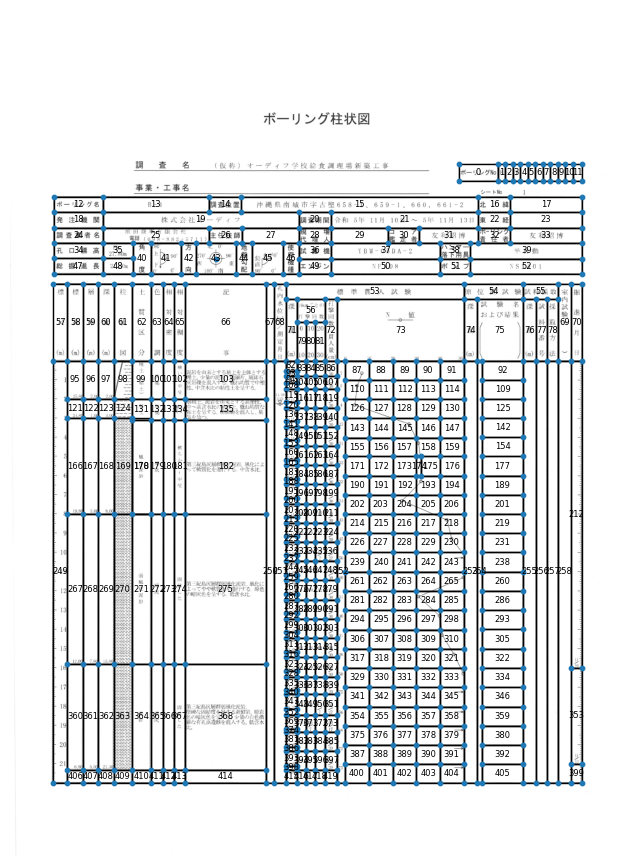

In [17]:
plot_cells_and_points(img, ordered_cells, intersections, figsize=(8, 11))

In [22]:
ordered_cells[9]

(2984.0, 694.0, 3027.0, 772.0)

In [23]:
ordered_cells.append((1448, 1214.0, 1581.0, 3968.0))

In [20]:
header = [12, 52]
soil = [58, 251]
spt = [53, 404]

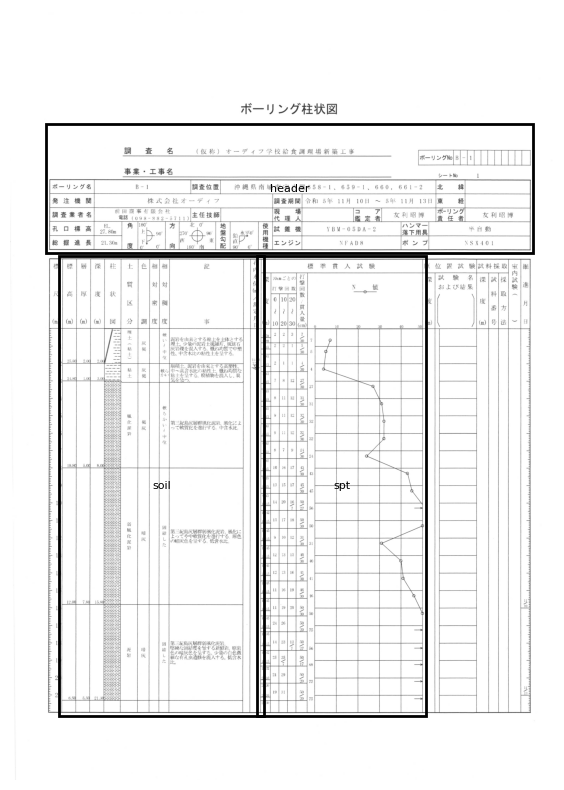

In [21]:
# Header
header_box = get_region(ordered_cells, header[0], header[1])
header_box = adjust(header_box, img.shape[1], img.shape[0], margin_top=340, margin=20)
header_box = norm_point(header_box, img.shape[1], img.shape[0], scale=1.0)

# Soil region
soil_box = get_region(ordered_cells, soil[0], soil[1])
soil_box = adjust(soil_box, img.shape[1], img.shape[0], margin_top=20, margin=20)
soil_box = norm_point(soil_box, img.shape[1], img.shape[0], scale=1.0)

# SPT region
spt_box = get_region(ordered_cells, spt[0], spt[1])
spt_box = adjust(spt_box, img.shape[1], img.shape[0], margin_top=20, margin=20)
spt_box = norm_point(spt_box, img.shape[1], img.shape[0], scale=1.0)

boxes = [header_box, soil_box, spt_box]
titles = ["header", "soil", "spt"]

show_ratio_boxes_overlay(img, boxes, box_titles=titles, figsize=(8, 10))

## Save dataset

In [26]:
uid = str(uuid.uuid4())
print(uid)

949d6fb8-bca1-4ce8-abbd-9289c3f66f16


In [ ]:
# save_yolo_sample_with_uuid(img, boxes, root_dir="yolo/borhole_regions_dataset", split="train", img_ext=".png", uid=uid)

Saved image to:  yolo/borhole_regions_dataset\images\train\949d6fb8-bca1-4ce8-abbd-9289c3f66f16.png
Saved labels to: yolo/borhole_regions_dataset\labels\train\949d6fb8-bca1-4ce8-abbd-9289c3f66f16.txt


# Train Model

In [12]:
import torch

print("cuda available:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)
print("num devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))

cuda available: True
cuda version: 12.8
num devices: 1
0 NVIDIA T400 4GB


In [13]:
from ultralytics import YOLO

# Load a pretrained YOLO model (nano = fastest)
model = YOLO("yolov8n.pt")

# Train
model.train(
    data="yolo/borhole_regions_dataset/dataset.yaml",  # the file we just wrote
    epochs=100,
    imgsz=512,
    batch=2,                       # tune based on your GPU/CPU RAM
    project="yolo_borehole_regions",
    name="yolov8n_regions_new",
    verbose=True,
)

New https://pypi.org/project/ultralytics/8.3.234 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.229  Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA T400 4GB, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo/borhole_regions_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_regions_new

RuntimeError: DataLoader worker (pid(s) 21228, 3308) exited unexpectedly

In [ ]:
model.val(
    data="yolo/borhole_regions_dataset/dataset.yaml",
    split="val",
    imgsz=1024,
)

Ultralytics 8.3.229  Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA T400 4GB, 4096MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 13,065 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.2 ms, read: 551.7516.0 MB/s, size: 4059.4 KB)
val: Scanning D:\Project\boring_reader\yolo\borhole_regions_dataset\labels\val.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15  0.0s


In [ ]:
results = model.predict(
    source="my_scan_deskewed.png",
    imgsz=1024,
    conf=0.25,
    save=True,
)


image 1/1 d:\Project\boring_reader\my_scan_deskewed.png: 1024x736 1 header_region, 1 soil_region, 1 spt_region, 90.0ms
Speed: 10.2ms preprocess, 90.0ms inference, 5.7ms postprocess per image at shape (1, 3, 1024, 736)
Results saved to D:\Project\boring_reader\runs\detect\predict


# Test model


image 1/1 d:\Project\boring_reader\output\my_scan_p1.png: 512x384 1 header_region, 1 soil_region, 1 spt_region, 62.6ms
Speed: 11.9ms preprocess, 62.6ms inference, 7.2ms postprocess per image at shape (1, 3, 512, 384)


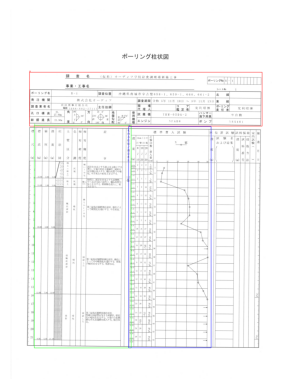

Saved: my_scan_deskewed_with_boxes.png
Detections:
soil_region (class 1): [xmin, ymin, xmax, ymax] = [306, 1469, 1529, 4284], conf = 0.984
spt_region (class 2): [xmin, ymin, xmax, ymax] = [1497, 1486, 2538, 4282], conf = 0.955
header_region (class 0): [xmin, ymin, xmax, ymax] = [246, 799, 3182, 1480], conf = 0.917


In [28]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# load model and run prediction
model = YOLO("yolo_borehole_regions/yolov8n_regions_new/weights/best.pt")
results = model("output/my_scan_p1.png", imgsz=512, conf=0.25, save=False)

r = results[0]

# base image (BGR -> RGB for plotting)
img = r.orig_img.copy()

# choose colors per class (BGR for cv2)
color_map = {
    0: (0, 0, 255),     # header_region -> red
    1: (0, 255, 0),     # soil_region   -> green
    2: (255, 0, 0),     # spt_region    -> blue (darker than default)
}

for box, cls in zip(r.boxes.xyxy.cpu().numpy(),
                    r.boxes.cls.cpu().numpy().astype(int)):
    x1, y1, x2, y2 = box.astype(int)
    color = color_map.get(cls, (255, 255, 255))

    # draw rectangle
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness=3)

    # optional: label text
    cv2.putText(
        img,
        f"{cls}",
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2,
        cv2.LINE_AA,
    )

# show result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

out_path = "my_scan_deskewed_with_boxes.png"
cv2.imwrite(out_path, img)
print("Saved:", out_path)

# --- 1. Absolute pixel coordinates [xmin, ymin, xmax, ymax] ---
bboxes_xyxy = r.boxes.xyxy.cpu().numpy()  # shape (N, 4), float32
bboxes_xyxy_int = bboxes_xyxy.astype(int).tolist()

# class ids for each box
class_ids = r.boxes.cls.cpu().numpy().astype(int)

# confidence scores for each box
confidences = r.boxes.conf.cpu().numpy()

label_map = {
    0: "header_region",
    1: "soil_region",
    2: "spt_region",
}

print("Detections:")
for box, cls_id, conf in zip(bboxes_xyxy_int, class_ids, confidences):
    label = label_map.get(cls_id, f"class_{cls_id}")
    print(
        f"{label} (class {cls_id}): "
        f"[xmin, ymin, xmax, ymax] = {box}, "
        f"conf = {conf:.3f}"
    )

In [ ]:
model = YOLO("yolo_borehole_regions/yolov8n_regions/weights/best.pt")
results = model("my_scan_deskewed.png", imgsz=1024, conf=0.25, save=False)

r = results[0]

# --- 1. Absolute pixel coordinates [xmin, ymin, xmax, ymax] ---
# r.boxes.xyxy is already in that order
bboxes_xyxy = r.boxes.xyxy.cpu().numpy()  # shape (N, 4), float32
bboxes_xyxy_int = bboxes_xyxy.astype(int).tolist()

# class ids for each box
class_ids = r.boxes.cls.cpu().numpy().astype(int)

# optional mapping from class id -> human-readable label
label_map = {
    0: "header_region",
    1: "soil_region",
    2: "spt_region",
}

print("Detections:")
for box, cls_id in zip(bboxes_xyxy_int, class_ids):
    label = label_map.get(cls_id, f"class_{cls_id}")
    print(f"{label} (class {cls_id}): [xmin, ymin, xmax, ymax] = {box}")



image 1/1 d:\Project\boring_reader\my_scan_deskewed.png: 1024x736 1 header_region, 1 soil_region, 1 spt_region, 38.1ms
Speed: 4.6ms preprocess, 38.1ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 736)
Detections:
header_region (class 0): [xmin, ymin, xmax, ymax] = [254, 797, 3169, 1468]
spt_region (class 2): [xmin, ymin, xmax, ymax] = [1498, 1503, 2523, 4304]
soil_region (class 1): [xmin, ymin, xmax, ymax] = [291, 1469, 1433, 4299]


In [ ]:
img = crop_image_file("my_scan_deskewed.png", bboxes_xyxy_int[2], margin=0, output_path="soil_region.png")

In [ ]:
# pip install -U langchain langchain-google-genai google-generativeai pydantic
import os
import json
import re
import base64
from typing import Any, Dict, List, Union

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage

from app.core.config import settings
import time


# ----------------------------
# CONFIG
# ----------------------------
API_KEY = settings.api_key

# Choose a Gemini model
MODEL_NAME = settings.chatbot_model
TEMPERATURE = 1.0

# Limit for thinking tokens (you can tune this)
# 0    = disable thinking (if model supports it)
# 1024 = “low” reasoning
# -1   = dynamic (model decides)
DEFAULT_THINKING_BUDGET = 4096


# ----------------------------
# UTIL: load instruction text
# ----------------------------
def load_instruction_text(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


# ----------------------------
# UTIL: strip code fences and parse JSON
# ----------------------------
def extract_json(text: str) -> Dict[str, Any]:
    """
    Extract JSON from a string that may contain markdown fences.
    """
    fence_match = re.search(r"```json\s*(\{.*?\})\s*```", text, flags=re.S)
    if fence_match:
        payload = fence_match.group(1)
    else:
        brace_match = re.search(r"(\{.*\})", text, flags=re.S)
        if not brace_match:
            raise ValueError("No JSON object found in the model output.")
        payload = brace_match.group(1)

    return json.loads(payload)


def _image_to_data_url(img: Union[str, bytes]) -> str:
    """
    Convert an image (file path or raw bytes) to a data URL for Gemini.

    Supports PNG / JPG / JPEG by extension. Defaults to image/png if unknown.
    """
    if isinstance(img, str):
        # treat as file path
        with open(img, "rb") as f:
            data = f.read()
        ext = os.path.splitext(img)[1].lower()
        if ext in [".jpg", ".jpeg"]:
            mime = "image/jpeg"
        else:
            mime = "image/png"
    else:
        # assume raw bytes
        data = img
        mime = "image/png"

    b64 = base64.b64encode(data).decode("ascii")
    return f"data:{mime};base64,{b64}"


def _flatten_gemini_content(content: Any) -> str:
    """
    Handle Gemini responses that may be:
      - a plain string, or
      - a list of parts like [{'type': 'text', 'text': '...'}, ...].

    Returns a single concatenated text string.
    """
    if content is None:
        return ""

    if isinstance(content, str):
        return content

    if isinstance(content, list):
        texts = []
        for part in content:
            if isinstance(part, dict):
                if part.get("type") == "text" and "text" in part:
                    texts.append(part["text"])
            else:
                t = getattr(part, "text", None)
                if isinstance(t, str):
                    texts.append(t)
        return "\n".join(texts)

    return str(content)


def transform_images_to_json(
    images: List[Union[str, bytes]],
    instruction_path: str = "image_ocr_instructions.txt",
    thinking_budget: int = DEFAULT_THINKING_BUDGET,
) -> Dict[str, Any]:
    """
    Send one or more images to Gemini with OCR-style instructions
    and get back JSON of the form:
        {
          "result": [...],
          "_usage": {
              "input_tokens": int | None,
              "output_tokens": int | None,
              "total_tokens": int | None
          }
        }

    - images: list of file paths or raw image bytes.
    - instruction_path: path to the instruction .txt you wrote.
    - thinking_budget: limit for internal reasoning tokens (Gemini thinking).
    """
    if not images:
        return {"result": [], "_usage": None}

    instruction_text = load_instruction_text(instruction_path).strip()

    llm = ChatGoogleGenerativeAI(
        model=MODEL_NAME,
        temperature=TEMPERATURE,
        api_key=API_KEY,
        # 🔽 limit reasoning / thinking tokens
        thinking_budget=thinking_budget,
        include_thoughts=False,  # don’t return thought summaries
    )

    parts: List[dict] = []

    parts.append({
        "type": "text",
        "text": (
            "You will now receive several images. For each image, extract text "
            "according to the instructions and then return one JSON object at the end."
        ),
    })

    for idx, img in enumerate(images, start=1):
        data_url = _image_to_data_url(img)
        parts.append({"type": "text", "text": f"Image {idx}:"})
        parts.append({"type": "image_url", "image_url": data_url})

    system_msg = SystemMessage(
        content=instruction_text + "\n\nImportant: Return ONLY the JSON object."
    )
    human_msg = HumanMessage(content=parts)

    response = llm.invoke([system_msg, human_msg])

    try:
        raw_text = _flatten_gemini_content(response.content).strip()
        parsed = extract_json(raw_text)

        usage = getattr(response, "usage_metadata", None)

        if isinstance(parsed, dict):
            parsed["_usage"] = usage
        else:
            parsed = {"result": parsed, "_usage": usage}

        return parsed

    except Exception as e:
        print("Failed to parse JSON from Gemini response.")
        print("Exception:", e)
        print("Raw content:", response.content)
        return None


c:\Users\DELL\anaconda3\envs\vevn3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
import json
import re
from typing import Any, Dict, List, Optional

from google import genai
from google.genai import types

from app.core.config import settings

API_KEY = settings.api_key
TEMPERATURE = 1.0


def load_instruction_text(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


def extract_json(text: str) -> Dict[str, Any]:
    """
    Extract JSON from a string that may contain markdown fences.
    """
    fence_match = re.search(r"```json\s*(\{.*?\})\s*```", text, flags=re.S)
    if fence_match:
        payload = fence_match.group(1)
    else:
        brace_match = re.search(r"(\{.*\})", text, flags=re.S)
        if not brace_match:
            raise ValueError("No JSON object found in the model output.")
        payload = brace_match.group(1)

    return json.loads(payload)


def _extract_text_from_gemini3_response(response: Any) -> str:
    """
    Extract text from a GenerateContentResponse in a way that works for Gemini 3.
    Priority:
      1. response.text
      2. response.output[*].content[*].text
      3. response.candidates[*].content.parts[*].text
    """
    txt = getattr(response, "text", None)
    if isinstance(txt, str) and txt.strip():
        return txt.strip()

    texts: List[str] = []

    # Gemini 3 style
    output = getattr(response, "output", None)
    if output:
        for out in output:
            content = getattr(out, "content", None)
            if not content:
                continue
            for part in content:
                t = getattr(part, "text", None)
                if isinstance(t, str) and t:
                    texts.append(t)
        if texts:
            return "\n".join(texts).strip()

    # Older candidate/parts style
    candidates = getattr(response, "candidates", None)
    if candidates:
        for c in candidates:
            content = getattr(c, "content", None)
            if not content:
                continue
            for p in getattr(content, "parts", []) or []:
                t = getattr(p, "text", None)
                if isinstance(t, str) and t:
                    texts.append(t)
        if texts:
            return "\n".join(texts).strip()

    return ""


def transform_images_to_json(
    image: bytes,
    instruction_path: str = "image_ocr_instructions.txt",
    image_mime_type: str = "image/png",
) -> Optional[Dict[str, Any]]:
    """
    Send a single image (as raw bytes) to Gemini-3 with OCR-style instructions
    and get back JSON of the form:
        {
          "result": [...],
          "_usage": { ... }
        }

    If the model call errors or times out, return None.
    """

    if not image:
        return {"result": [], "_usage": None}

    instruction_text = load_instruction_text(instruction_path).strip()

    if not isinstance(image, (bytes, bytearray)):
        raise TypeError(f"image must be bytes, got {type(image)}")

    contents: List[Any] = [
        types.Part.from_bytes(
            data=bytes(image),
            mime_type=image_mime_type,
        ),
    ]

    # 90 seconds = 90_000 ms for HttpOptions.timeout
    http_options = types.HttpOptions(timeout=90_000)

    client = genai.Client(
        api_key=API_KEY,
        http_options=http_options,
    )

    gen_config = types.GenerateContentConfig(
        temperature=TEMPERATURE,
        response_mime_type="application/json",
        system_instruction=(
            instruction_text
        ),
        thinking_config=types.ThinkingConfig(thinking_level="low"),
    )

    try:
        response = client.models.generate_content(
            model="gemini-3-pro-preview",
            contents=contents,
            config=gen_config,
        )
    except Exception as e:
        # This will include HTTP timeouts enforced by HttpOptions
        print("Gemini generate_content call failed:", e)
        return None

    try:
        raw_text = _extract_text_from_gemini3_response(response)
        if not raw_text:
            raise ValueError("Empty text in Gemini-3 response")

        parsed = extract_json(raw_text)

        usage_meta = getattr(response, "usage_metadata", None)
        if usage_meta is not None:
            usage = {
                "input_tokens": getattr(usage_meta, "prompt_token_count", None),
                "output_tokens": getattr(usage_meta, "candidates_token_count", None),
                "total_tokens": getattr(usage_meta, "total_token_count", None),
            }
        else:
            usage = None

        if isinstance(parsed, dict):
            parsed["_usage"] = usage
        else:
            parsed = {"result": parsed, "_usage": usage}

        return parsed

    except Exception as e:
        print("Failed to parse JSON from Gemini response.")
        print("Exception:", e)
        print("Raw text:", _extract_text_from_gemini3_response(response))
        return None


In [33]:
import cv2
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from ultralytics import YOLO

# maps from class id -> instruction file path
instructions_map = {
    0: "yolo/instructions/boring_instruction_header.txt",
    1: "yolo/instructions/boring_instruction_soil.txt",
    2: "yolo/instructions/boring_instruction_spt.txt",
}

# maps from class id -> human readable label
label_map = {
    0: "header_region",
    1: "soil_region",
    2: "spt_region",
}

model = YOLO("yolo_borehole_regions/yolov8n_regions/weights/best.pt")


def crop_img_to_png_bytes(img: np.ndarray, box_xyxy):
    """
    Crop image to [xmin, ymin, xmax, ymax] box (in pixels)
    and return PNG bytes for LLM.
    """
    img_bit = crop_image_array(img, box_xyxy, margin=0)
    return image_array_to_png_bytes(img_bit)

def draw_box(img, r, out_path = "my_scan_deskewed_with_boxes.png"):
    # choose colors per class (BGR for cv2)
    color_map = {
        0: (0, 0, 255),     # header_region -> red
        1: (0, 255, 0),     # soil_region   -> green
        2: (255, 0, 0),     # spt_region    -> blue (darker than default)
    }
    label_map = {
        0: "header_region",
        1: "soil_region",
        2: "spt_region",
    }

    for box, cls in zip(r.boxes.xyxy.cpu().numpy(),
                        r.boxes.cls.cpu().numpy().astype(int)):
        x1, y1, x2, y2 = box.astype(int)
        color = color_map.get(cls, (255, 255, 255))

        # draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness=3)

        # optional: label text
        cv2.putText(
            img,
            f"{label_map[cls]}",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            color,
            2,
            cv2.LINE_AA,
        )

    # show result
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    cv2.imwrite(out_path, img)
    print("Saved:", out_path)


def process_boring_log(model: YOLO, img_path: str):
    """
    1. Run YOLO to detect 3 regions: header, soil, spt.
    2. Enforce exactly one bbox per region (0,1,2).
       - If any missing => error
       - If multiple => keep highest-confidence
    3. Crop each region, send to transform_images_to_json in parallel.
    4. Accumulate token usage and return results per region label.
    """
    boring_result = {}

    # ------------------------------------------------------------------
    # 1) Run YOLO once on image
    # ------------------------------------------------------------------
    results = model(img_path, imgsz=1024, conf=0.25, save=False)
    r = results[0]

    if r.boxes is None or len(r.boxes) == 0:
        raise RuntimeError("No detections from YOLO for this image")

    # original image (for cropping)
    img = r.orig_img  # BGR

    # detections
    bboxes_xyxy = r.boxes.xyxy.cpu().numpy()        # (N,4) float
    class_ids   = r.boxes.cls.cpu().numpy().astype(int)  # (N,)
    confidences = r.boxes.conf.cpu().numpy()       # (N,)

    # ------------------------------------------------------------------
    # 2) Pick best detection per desired class (0,1,2)
    # ------------------------------------------------------------------
    desired_classes = {0, 1, 2}
    best_idx_per_class = {}
    best_conf_per_class = {}

    for i, (cls_id, conf) in enumerate(zip(class_ids, confidences)):
        if cls_id not in desired_classes:
            continue
        if cls_id not in best_idx_per_class or conf > best_conf_per_class[cls_id]:
            best_idx_per_class[cls_id] = i
            best_conf_per_class[cls_id] = conf

    # Check we have exactly one bbox for each class 0/1/2
    missing = desired_classes - set(best_idx_per_class.keys())
    if missing:
        raise RuntimeError(
            f"YOLO did not detect all required regions. Missing classes: {sorted(missing)}"
        )

    # ------------------------------------------------------------------
    # 3) Build jobs: one job per region (header/soil/spt)
    # ------------------------------------------------------------------
    jobs = []  # each job: (region_label, images_bits_list, instruction_path)

    print("Detections after filtering (one per class):")
    for cls_id in sorted(desired_classes):
        idx = best_idx_per_class[cls_id]
        box = bboxes_xyxy[idx].astype(int).tolist()  # [xmin, ymin, xmax, ymax]
        label = label_map[cls_id]
        instruction_path = instructions_map[cls_id]

        print(
            f"{label} (class {cls_id}, conf={best_conf_per_class[cls_id]:.3f}): "
            f"[xmin, ymin, xmax, ymax] = {box}"
        )

        image_bytes = crop_img_to_png_bytes(img, box)
        jobs.append((
            label,              # kind / region label
            [image_bytes],      # images: list of PNG bytes
            instruction_path,   # instruction file path
        ))
    draw_box(img, r)
    print("Sending extraction...")
    # ------------------------------------------------------------------
    # 4) Define worker to call LLM for one region
    # ------------------------------------------------------------------
    def run_job(kind, images_bits, instruction_path):
        # NOTE: assumes you already have transform_images_to_json defined elsewhere
        result = transform_images_to_json(
            images=images_bits,
            instruction_path=instruction_path,
        )
        return kind, result

    # token usage accumulators
    total_input_tokens = 0
    total_output_tokens = 0
    total_tokens = 0

    # ------------------------------------------------------------------
    # 5) Run all region jobs in parallel
    # ------------------------------------------------------------------
    max_workers = min(3, len(jobs))  # at most 3 jobs (header, soil, spt)
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_kind = {
            executor.submit(run_job, kind, images_bits, instruction_path): kind
            for (kind, images_bits, instruction_path) in jobs
        }

        for future in as_completed(future_to_kind):
            kind = future_to_kind[future]
            try:
                kind_ret, result = future.result()
            except Exception as e:
                print(f"[ERROR] Job {kind} failed: {e}")
                continue

            # --- accumulate token usage (if provided) ---
            usage = result.get("_usage") if isinstance(result, dict) else None
            if usage:
                in_tok = usage.get("input_tokens") or 0
                out_tok = usage.get("output_tokens") or 0
                tot_tok = usage.get("total_tokens") or 0

                total_input_tokens += in_tok
                total_output_tokens += out_tok
                total_tokens += tot_tok

            # --- flatten result payload ---
            # result is whatever transform_images_to_json returned for this region
            # Usually the actual content is under "borehole_log"
            payload = result.get("borehole_log", result)

            if kind_ret == "header_region":
                # Expecting payload["header_info"]
                header_info = payload.get("header_info")
                boring_result["header_info"] = header_info

            elif kind_ret == "soil_region":
                # Expecting payload["soil_layers"]
                soil_layers = payload.get("soil_layers")
                boring_result["soil_layers"] = soil_layers

            elif kind_ret == "spt_region":
                # Expecting payload["spt_tests"]
                spt_tests = payload.get("spt_tests")
                boring_result["spt_tests"] = spt_tests

    # ------------------------------------------------------------------
    # 6) Print total token usage
    # ------------------------------------------------------------------
    print(
        f"Total token usage for this boring log: "
        f"input={total_input_tokens}, "
        f"output={total_output_tokens}, "
        f"total={total_tokens}"
    )

    print("All regions extracted.")
    return boring_result


In [33]:
PATH = "D:\\Project\\ai_training\\app\\boring (30).pdf"
typ = "pdf"
delete_all_files_in_folder("output")
file = read_file_as_binary(PATH)

imgs = pdf_bytes_to_images(
    file,
    dpi=400,
    fmt="png",
    save_dir="output",  # or None to skip saving
    base_filename="my_scan"           # filename prefix for saved files
)

print(f"Returned {len(imgs)} images as bytes.")



Deleted 0 files in: output
Returned 3 images as bytes.


In [30]:
import json

In [37]:
import concurrent.futures
from typing import Any, Dict, Optional, List


def race_transform_images(
    image_bytes: bytes,
    instruction_path: str,
    num_requests: int = 3,
) -> Optional[Dict[str, Any]]:
    """
    Run multiple transform_images_to_json calls in parallel and return the first
    successful result (non-None).

    - Launch `num_requests` parallel calls.
    - Each call has its own HTTP timeout inside transform_images_to_json.
    - As soon as one call returns a non-None result:
        -> return that result and stop waiting for the others.
    - If all calls finish and all return None:
        -> return None.

    NOTE: We do *not* wait for remaining futures to finish; they may keep
    running in the background until their own timeouts, but we don't block on them.
    """

    def _worker():
        return transform_images_to_json(
            image=image_bytes,
            instruction_path=instruction_path,
        )

    executor = concurrent.futures.ThreadPoolExecutor(max_workers=num_requests)
    futures: List[concurrent.futures.Future] = [
        executor.submit(_worker) for _ in range(num_requests)
    ]

    winner_result: Optional[Dict[str, Any]] = None

    try:
        # as_completed yields futures as they finish
        for f in concurrent.futures.as_completed(futures):
            try:
                res = f.result()
            except Exception as e:
                print("Worker raised exception:", e)
                res = None

            if res is not None:
                winner_result = res
                break

    finally:
        # We have a winner or all failed; we don't want to wait for the rest.
        for f in futures:
            # Try to cancel futures that haven't started or are pending.
            if not f.done():
                f.cancel()

        # Do not wait for threads to finish; let them wind down on their own.
        executor.shutdown(wait=False)

    return winner_result


In [31]:
crop = cv2.imread("spt_region.png") 
bit = image_array_to_png_bytes(crop) 
result = transform_images_to_json(image=bit, instruction_path="yolo/instructions/boring_instruction_spt.txt") 
print(json.dumps(result, ensure_ascii=False, indent=2))

Gemini generate_content call failed: The read operation timed out
null


In [38]:

# ----------------- Your original flow, now using race -----------------

crop = cv2.imread("spt_region.png")
bit = image_array_to_png_bytes(crop)

result = race_transform_images(
    image_bytes=bit,
    instruction_path="yolo/instructions/boring_instruction_spt.txt",
    num_requests=3,        # or more if you want
)

if result is not None:
    print(json.dumps(result, ensure_ascii=False, indent=2))
else:
    print("All parallel requests timed out or returned None.")


{
  "borehole_log": {
    "spt_tests": [
      {
        "test_depth_range_m": [
          0.5,
          0.8
        ],
        "blow_counts_0_10cm": 2,
        "blow_counts_10_20cm": 2,
        "blow_counts_20_30cm": 3,
        "penetration_cm": 30,
        "n_value": 7
      },
      {
        "test_depth_range_m": [
          1.15,
          1.45
        ],
        "blow_counts_0_10cm": 2,
        "blow_counts_10_20cm": 2,
        "blow_counts_20_30cm": 1,
        "penetration_cm": 30,
        "n_value": 5
      },
      {
        "test_depth_range_m": [
          2.15,
          2.45
        ],
        "blow_counts_0_10cm": 2,
        "blow_counts_10_20cm": 1,
        "blow_counts_20_30cm": 1,
        "penetration_cm": 30,
        "n_value": 4
      },
      {
        "test_depth_range_m": [
          3.15,
          3.45
        ],
        "blow_counts_0_10cm": 7,
        "blow_counts_10_20cm": 8,
        "blow_counts_20_30cm": 12,
        "penetration_cm": 30,
        "n_value":

Estimated skew from vertical lines (avg): 0.982 degrees
Rotated by: -0.9816498024746778

image 1/1 d:\Project\boring_reader\my_scan_deskewed.png: 1024x736 1 header_region, 1 soil_region, 1 spt_region, 46.8ms
Speed: 4.3ms preprocess, 46.8ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 736)
Detections after filtering (one per class):
header_region (class 0, conf=0.998): [xmin, ymin, xmax, ymax] = [257, 797, 3176, 1468]
soil_region (class 1, conf=0.990): [xmin, ymin, xmax, ymax] = [296, 1478, 1438, 4298]
spt_region (class 2, conf=0.998): [xmin, ymin, xmax, ymax] = [1504, 1499, 2527, 4294]


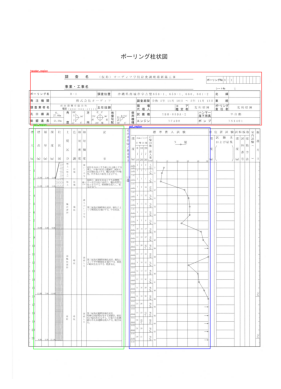

Saved: my_scan_deskewed_with_boxes.png
Sending extraction...
Total token usage for this boring log: input=3365, output=13815, total=17180
All regions extracted.
Save json in  boring_output.json


In [ ]:
img = cv2.imread("output/my_scan_p1.png")
img_path = "my_scan_deskewed.png"
output_path = "boring_output.json"

if img is None:
    raise FileNotFoundError("Could not read image")

deskewed, skew = deskew_image_by_vertical(img, max_vertical_deviation=10.0, min_frac_of_height=0.4)
print("Rotated by:", -skew)
img = deskewed   
cv2.imwrite(img_path, deskewed)

result = process_boring_log(model, img_path)
json.dump(result, open(output_path, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
print("Save json in ", output_path)